In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import about, basis, destroy, mcsolve, mesolve, sigmam, sigmax
import pandas as pd
import lmfit
import corner
import emcee
from pylab import *
ion()

%matplotlib inline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [48]:
# number of modes
N = 2
# Destroy operator
a = destroy(N)
# oscillator Hamiltonian
H = a.dag() * a
# Initial excited (1) state
psi0 = basis(N, 1)

#dissipative terms
gamma_relax=5.0
k=0.5

#collapse operator
c_ops = []
c_ops.append(np.sqrt(k) * sigmam()) #c1= sqrt(kappa)*signam_- ------excitation
c_ops.append(np.sqrt(gamma_relax)*a) #c2= sqrt(kappa)*a -----decay

In [76]:
ntraj = [1, 5, 15, 904]  # number of MC trajectories
t_final=2
tlist = np.linspace(0, t_final, 1000)

# Solve using MCSolve for different ntraj
mc_try = mcsolve(H, psi0, tlist, c_ops, [a.dag() * a], ntraj)
me = mesolve(H, psi0, tlist, c_ops, [a.dag() * a])

10.1%. Run time:   0.38s. Est. time left: 00:00:00:03
20.0%. Run time:   0.61s. Est. time left: 00:00:00:02
30.1%. Run time:   0.87s. Est. time left: 00:00:00:02
40.0%. Run time:   1.12s. Est. time left: 00:00:00:01
50.0%. Run time:   1.36s. Est. time left: 00:00:00:01
60.1%. Run time:   1.59s. Est. time left: 00:00:00:01
70.0%. Run time:   1.83s. Est. time left: 00:00:00:00
80.1%. Run time:   2.07s. Est. time left: 00:00:00:00
90.0%. Run time:   2.31s. Est. time left: 00:00:00:00
100.0%. Run time:   2.53s. Est. time left: 00:00:00:00
Total run time:   2.54s


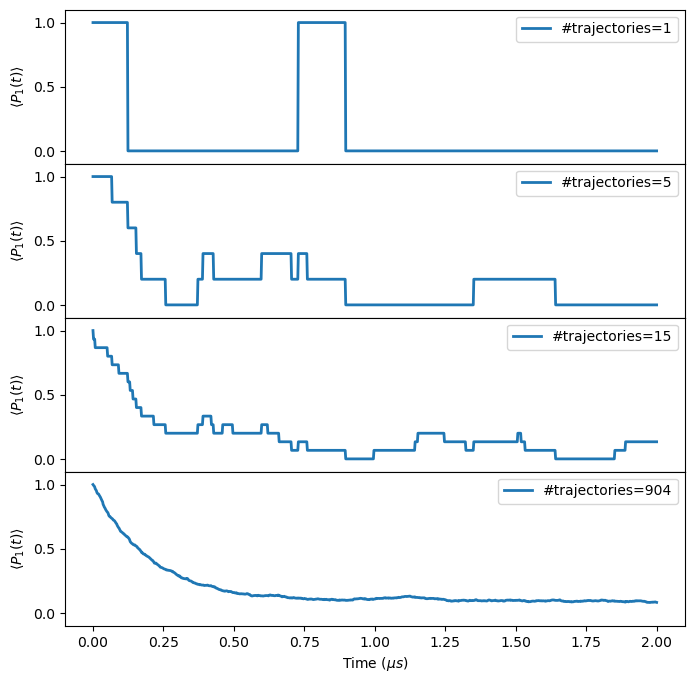

In [78]:
#Plot basic simulation of MC solver for different n. of trajectories
fig = plt.figure(figsize=(8, 8), frameon=False)
plt.subplots_adjust(hspace=0.0)

for i in range(4):
    ax = plt.subplot(4, 1, i + 1)
    ax.plot(
        tlist, mc_try.expect[i][0], lw=2,
        label="#trajectories={}".format(ntraj[i])
    )
    #ax.plot(tlist, me.expect[0], "r--", lw=2)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_ylabel(r"$\langle P_{1}(t)\rangle$")
    ax.legend()

ax.set_xlabel(r"Time ($\mu s$)");

plt.savefig("trajectories.pdf")

In [61]:
# MLE data preparation
y = mc_try.expect[3][0]
x = tlist
n = len (tlist)

In [62]:
# Initializing our example creating a parameter set for the initial guesses:
p = lmfit.Parameters()
p.add_many(('a', 5),('b', .5)) #a=gamma_relax= 5, b=k=.5


def residual(p):
    v = p.valuesdict()
    return (v['b']/(v['b']+v['a'])) + (1 - (v['b']/(v['b']+v['a'])))*np.exp(-x*(v['a']+v['b'])) - y

[[Variables]]
    a:  4.92957134 (init = 5)
    b:  0.55141972 (init = 0.5)


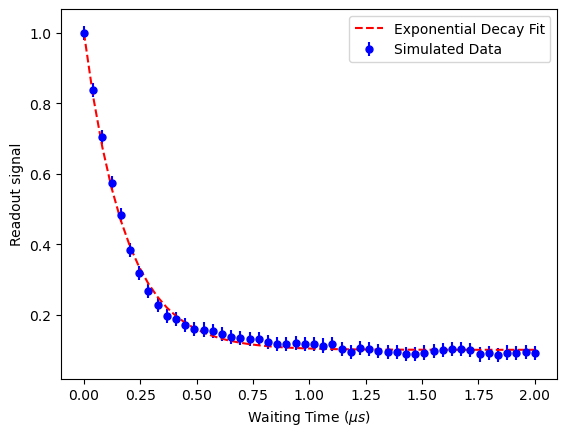

In [63]:
#Solving with minimize() gives the Maximum Likelihood solution.:

mi = lmfit.minimize(residual, p, method='Nelder')
lmfit.printfuncs.report_fit(mi.params, min_correl=0.5)

plt.errorbar(tlist, mc_try.expect[3][0],yerr=0.02, markersize=5,label='Simulated Data', color="blue", fmt='o')

#plt.plot(x, (k/(gamma_relax+k)) + ( 1 - (k/(gamma_relax+k)))*np.exp(-x*(k+gamma_relax)),label='analytical sol.')
plt.plot(x, residual(mi.params) + y, 'r--',label='Exponential Decay Fit')
plt.ylabel('Readout signal')
plt.xlabel(r'Waiting Time ($\mu s$)')
plt.legend()

plt.savefig("T1example.pdf")
plt.show()

In [131]:
### 1-SHOT SOLVER
#numerical solver to find the optimal sampling point (x_opt as) a function of gamma
from scipy.optimize import fsolve
import numpy as np

# Define the equation d_gamma=0 as a function
def equation(x, gamma, t):
    return 2*np.sqrt((t+x)/x**2)*np.sqrt(np.exp(gamma*x)-1)

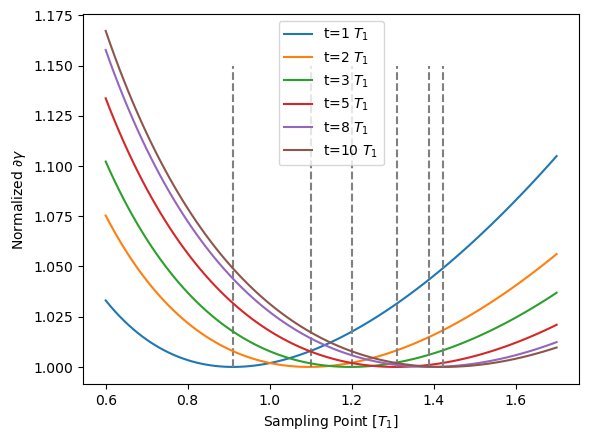

In [147]:
tt=np.linspace(0.6,1.7,100)
res=equation(tt,gamma_value,t_wait)

a=[1,2,3,5,8,10]

for t_wait in a:
    plt.plot(tt,equation(tt,gamma_value,t_wait)/np.min(equation(tt,gamma_value,t_wait)),label=f"t={t_wait} $T_1$")
    plt.vlines(tt[np.argmin(equation(tt,gamma_value,t_wait))],1,1.15, linestyle='dashed', color='grey')
plt.ylabel("Normalized $\partial \gamma$")
plt.xlabel("Sampling Point [$T_1$]")
plt.legend()
plt.savefig("minimum1p.pdf")

In [148]:
# Define the equation d_gamma=0 as a function
def equation1(x, gamma):
    return 1/np.sqrt(x) * np.sqrt(np.exp(gamma*x)-1)

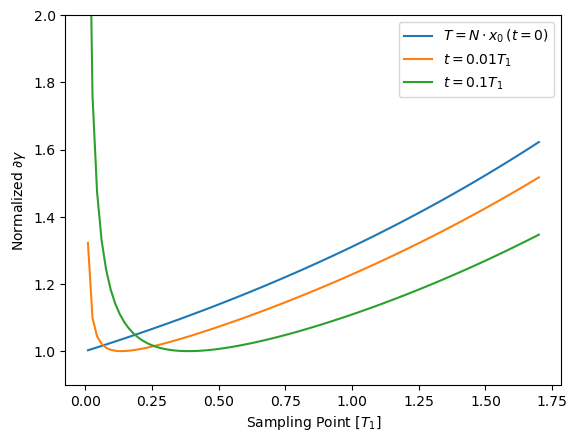

In [178]:
ttt=np.linspace(0.01,1.7,100)
plt.plot(ttt,equation1(ttt,1),label="$T=N\cdot x_0 \, (t=0)$")
plt.plot(ttt,equation(ttt,1,0.01)/np.min(equation(ttt,1,0.01)),label="$t=0.01 T_1$")
plt.plot(ttt,equation(ttt,1,0.1)/np.min(equation(ttt,1,0.1)),label="$t=0.1 T_1$")
plt.ylim(0.9,2)
plt.ylabel("Normalized $\partial \gamma$")
plt.xlabel("Sampling Point [$T_1$]")
plt.legend()
plt.savefig("minimum1pt0.pdf")
